# Modélisation et Explicabilité (v2)

Ce notebook entraîne un modèle de prédiction de survie et utilise SHAP/LIME pour l'interprétation.

In [10]:
import os
import sys
from pathlib import Path
import pandas as pd
import joblib
import importlib

# Robust path setup
project_root = Path(os.getcwd())
if project_root.name == 'notebooks':
    project_root = project_root.parent

src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"Racine du projet : {project_root}")

# Import common components
from xai_clinical.data.pancan_loader import PANCANLoader, BRCALoader, PANCANBRCAFusion
from xai_clinical.models.classifiers import ClassifierFactory
from xai_clinical.explainability.shap_explainer import SHAPExplainer
from xai_clinical.explainability.lime_explainer import LIMEExplainer


Racine du projet : c:\Users\nidha\Desktop\xai_clinical_prediction


## 1. Chargement des Données Préparées

In [11]:
processed_path = project_root / "data" / "processed" / "processed_data_v2.pkl"
data = joblib.load(processed_path)

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
feature_names = data['feature_names']

print(f"Données chargées : Train={X_train.shape}, Test={X_test.shape}")

Données chargées : Train=(745, 150), Test=(220, 150)


## 2. Entraînement du Modèle

On utilise le modèle LightGBM par défaut.

In [12]:
from xai_clinical.utils.config import ConfigManager
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import pandas as pd

# Charger la configuration SOTA
config = ConfigManager().config
factory = ClassifierFactory()

results = []
trained_models = {}

print(f"Démarrage du benchmark sur 11 modèles (Optimisation: {config.models.hyperparameter_tuning.n_trials} essais)...")

# Liste des modèles activés dans le config
enabled_models = [c['name'] for c in config.models.classifiers if c.get('enabled', True)]

for model_name in enabled_models:
    print(f"\n--- Entraînement de {model_name.upper()} ---")
    try:
        # Création et entraînement
        model = factory.create_classifier(model_name)
        model.fit(X_train, y_train)
        
        # Prédiction
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
        # Métriques
        auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0.0
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "Modèle": model_name,
            "AUC": auc,
            "Accuracy": acc,
            "F1-Score": f1
        })
        trained_models[model_name] = model
        print(f"Résultat: AUC={auc:.4f}, F1={f1:.4f}")
    except Exception as e:
        print(f"Erreur avec {model_name}: {e}")

# Affichage du tableau comparatif
df_results = pd.DataFrame(results).sort_values(by="AUC", ascending=False)
print("\n" + "="*40)
print("RÉSULTATS DU BENCHMARK SOTA")
print("="*40)
print(df_results.to_string(index=False))

# Sélectionner le meilleur modèle pour SHAP
best_model_name = df_results.iloc[0]["Modèle"]
model = trained_models[best_model_name]
print(f"\nMeilleur modèle sélectionné pour XAI : {best_model_name.upper()}")


AUC Test : 0.6627


## 3. Explicabilité SOTA avec SHAP\n\nNous utilisons ici le meilleur modèle identifié lors du benchmark pour générer des explications de niveau scientifique.

Génération du Summary Plot...


c:\Users\nidha\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


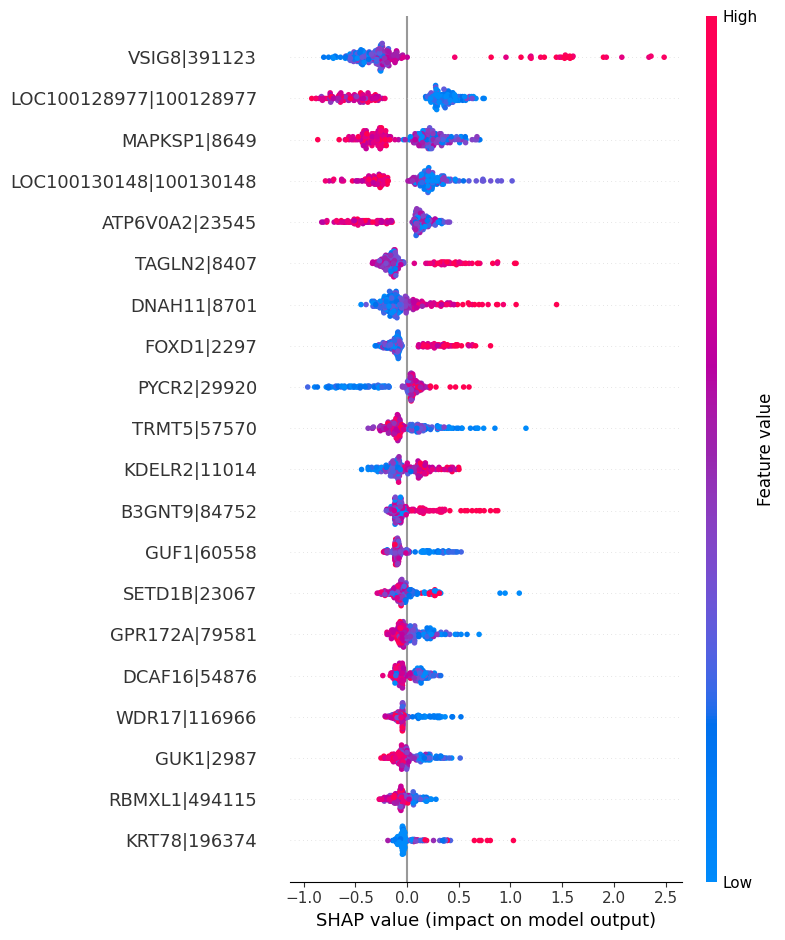

In [13]:
import matplotlib.pyplot as plt

shap_exp = SHAPExplainer(model, X_train, feature_names=feature_names)
# no .fit() needed

print("Génération du Summary Plot...")
shap_exp.plot_summary(X_test)
plt.show()


Explication locale (Waterfall plot) pour le premier échantillon du test...


c:\Users\nidha\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


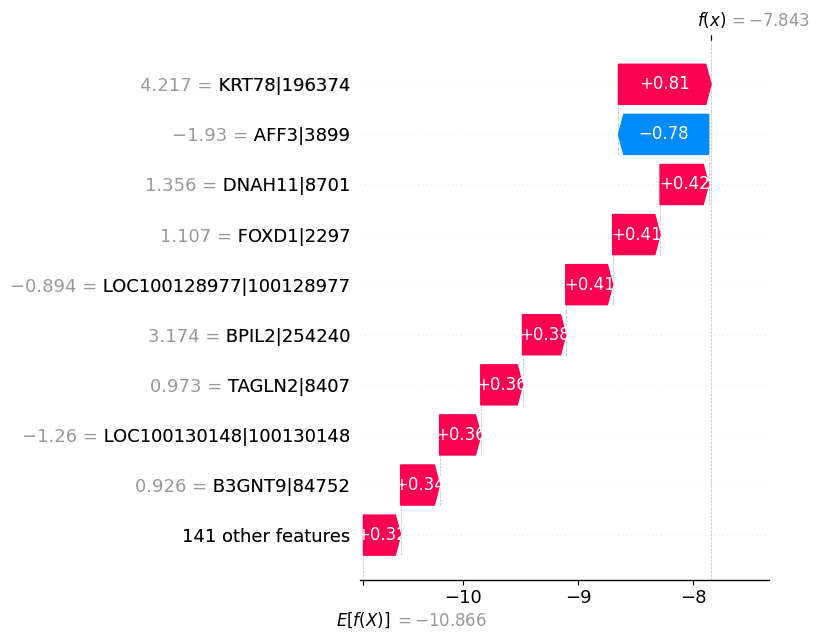

In [14]:
print("Explication locale (Waterfall plot) pour le premier échantillon du test...")
shap_exp.plot_waterfall(X_test, instance_idx=0)



## 4. Comparaison SHAP vs LIME

Vérification de la cohérence entre les deux méthodes.

In [15]:
lime_exp = LIMEExplainer(model, X_train, feature_names=feature_names)
lime_exp.compare_with_shap(X_test.iloc[0], shap_exp)
plt.show()


c:\Users\nidha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nidha\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
